# CNN Variant Evaluation on Oxford Flowers 102

This notebook evaluates and compares all CNN variants trained on the Oxford Flowers 102 dataset. It loads each model checkpoint, runs inference on the test set, and generates comparison metrics and visualizations.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, balanced_accuracy_score)
from tqdm.notebook import tqdm

from models import MODEL_REGISTRY
from utils.data_loader import get_dataloaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Load Test Data

In [2]:
_, _, test_loader = get_dataloaders(batch_size=32)
print(f"Test set: {len(test_loader.dataset)} images")

Test set: 6149 images


## Evaluation Function

In [3]:
def evaluate_model(model_name, checkpoint_path):
    """Load checkpoint and evaluate on test set. Returns preds, labels, all_logits."""
    model = MODEL_REGISTRY[model_name](num_classes=102).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    model.eval()
    
    all_preds = []
    all_labels = []
    all_logits = []
    
    with torch.no_grad():
        for inputs, targets in tqdm(test_loader, desc=f"Evaluating {model_name}"):
            inputs = inputs.to(device)
            logits, _ = model(inputs)
            _, predicted = torch.max(logits, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(targets.numpy())
            all_logits.append(logits.cpu().numpy())
    
    preds = np.array(all_preds)
    labels = np.array(all_labels)
    logits_all = np.concatenate(all_logits, axis=0)
    
    # Metrics following Nilsback & Zisserman (2008): mean per-class accuracy
    acc = accuracy_score(labels, preds)
    mean_per_class_acc = balanced_accuracy_score(labels, preds)
    
    # Top-5 accuracy
    top5_preds = np.argsort(logits_all, axis=1)[:, -5:]
    top5_correct = np.array([labels[i] in top5_preds[i] for i in range(len(labels))])
    top5_acc = top5_correct.mean()
    
    print(f"{model_name}: Accuracy={acc:.4f} | Mean Per-Class Acc={mean_per_class_acc:.4f} | Top-5={top5_acc:.4f}")
    return preds, labels, logits_all, acc, mean_per_class_acc, top5_acc

## Evaluate All Models

In [4]:
# Evaluate all trained models
results = {}

for model_name in MODEL_REGISTRY.keys():
    checkpoint = f'../results/checkpoints/best_{model_name}.pth'
    if os.path.exists(checkpoint):
        preds, labels, logits, acc, mpc_acc, top5 = evaluate_model(model_name, checkpoint)
        results[model_name] = {
            'preds': preds, 'labels': labels, 'logits': logits,
            'acc': acc, 'mean_per_class_acc': mpc_acc, 'top5_acc': top5
        }
    else:
        print(f"Skipping {model_name}: no checkpoint found at {checkpoint}")

Evaluating baseline:   0%|          | 0/193 [00:00<?, ?it/s]

baseline: Accuracy=0.8377 | Mean Per-Class Acc=0.8640 | Top-5=0.9537


Evaluating dilated:   0%|          | 0/193 [00:00<?, ?it/s]

dilated: Accuracy=0.7595 | Mean Per-Class Acc=0.7853 | Top-5=0.9141


Evaluating deformable:   0%|          | 0/193 [00:00<?, ?it/s]

deformable: Accuracy=0.8133 | Mean Per-Class Acc=0.8346 | Top-5=0.9431


Evaluating depthwise:   0%|          | 0/193 [00:00<?, ?it/s]

depthwise: Accuracy=0.5703 | Mean Per-Class Acc=0.5971 | Top-5=0.8154


Evaluating hybrid:   0%|          | 0/193 [00:00<?, ?it/s]

hybrid: Accuracy=0.7873 | Mean Per-Class Acc=0.8134 | Top-5=0.9301


## Results Summary

In [5]:
# Summary table with all metrics (following Nilsback & Zisserman 2008)
if results:
    summary = pd.DataFrame({
        'Model': list(results.keys()),
        'Accuracy': [r['acc'] for r in results.values()],
        'Mean Per-Class Acc': [r['mean_per_class_acc'] for r in results.values()],
        'Top-5 Acc': [r['top5_acc'] for r in results.values()],
        'Params': [sum(p.numel() for p in MODEL_REGISTRY[n](num_classes=102).parameters() if p.requires_grad) for n in results.keys()]
    })
    summary = summary.sort_values('Mean Per-Class Acc', ascending=False).reset_index(drop=True)
    summary['Params'] = summary['Params'].apply(lambda x: f"{x:,}")
    
    # Format percentages
    for col in ['Accuracy', 'Mean Per-Class Acc', 'Top-5 Acc']:
        summary[col] = summary[col].apply(lambda x: f"{x:.4f}")
    
    print("Primary metric: Mean Per-Class Accuracy (following Nilsback & Zisserman, 2008)")
    print()
    print(summary.to_string(index=False))

Primary metric: Mean Per-Class Accuracy (following Nilsback & Zisserman, 2008)

     Model Accuracy Mean Per-Class Acc Top-5 Acc     Params
  baseline   0.8377             0.8640    0.9537 11,228,838
deformable   0.8133             0.8346    0.9431 11,415,534
    hybrid   0.7873             0.8134    0.9301 11,353,290
   dilated   0.7595             0.7853    0.9141 11,228,838
 depthwise   0.5703             0.5971    0.8154  1,623,270


## Confusion Matrices

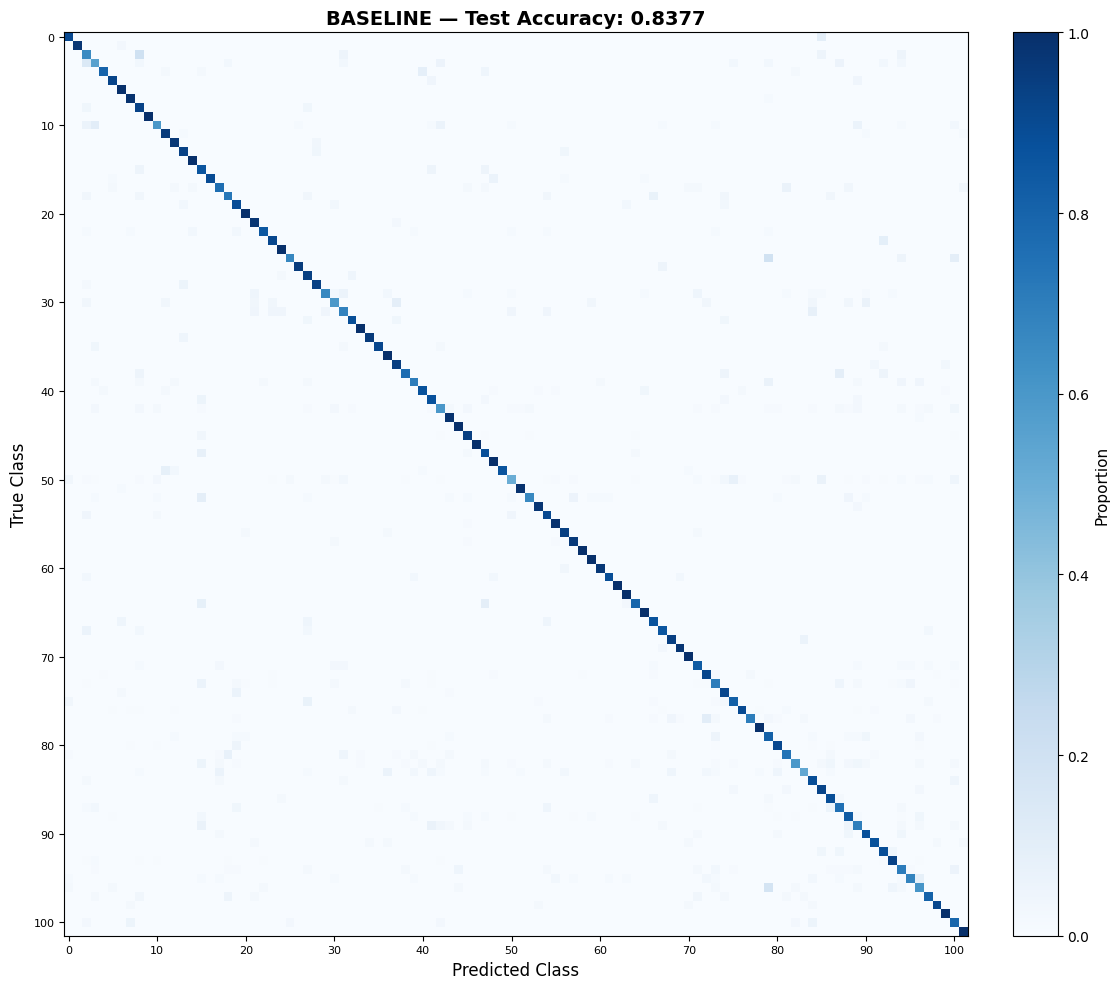

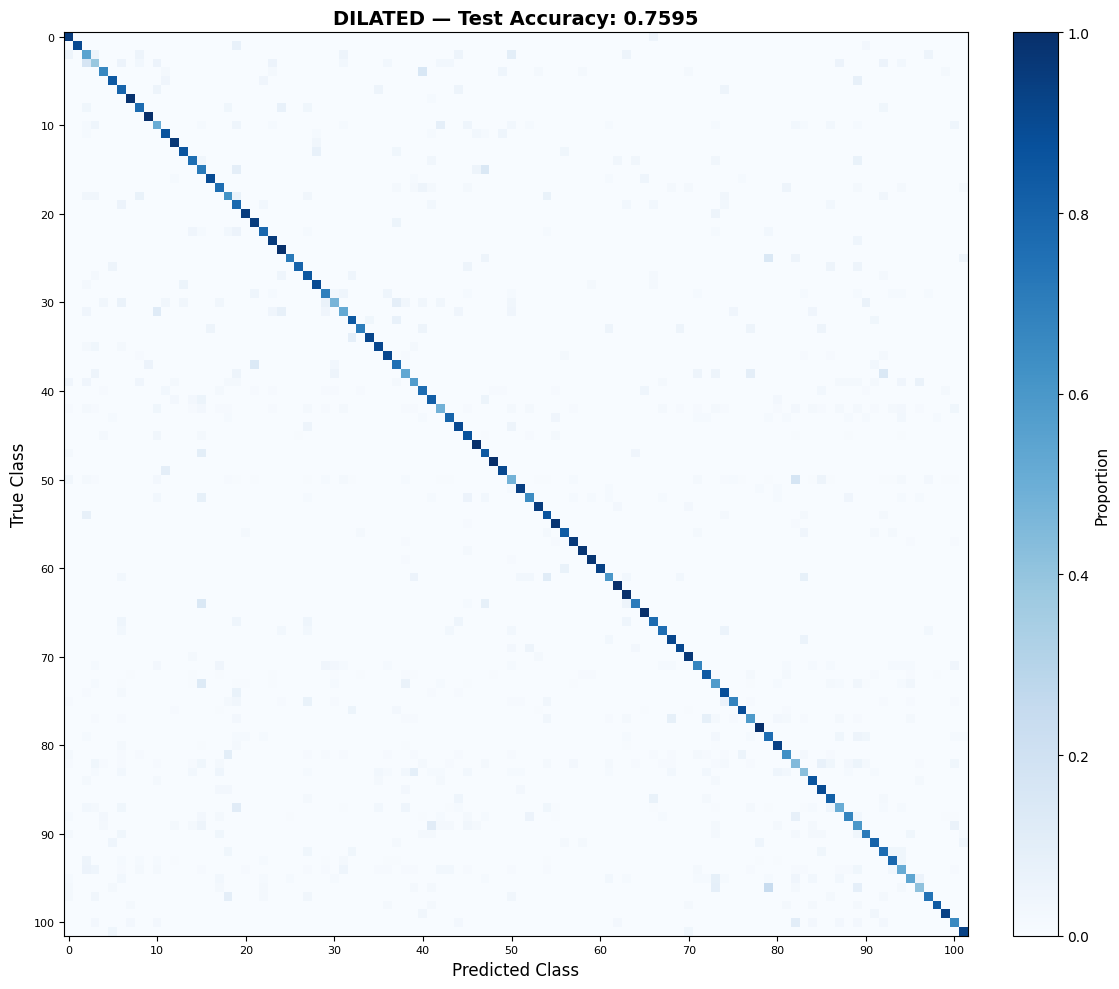

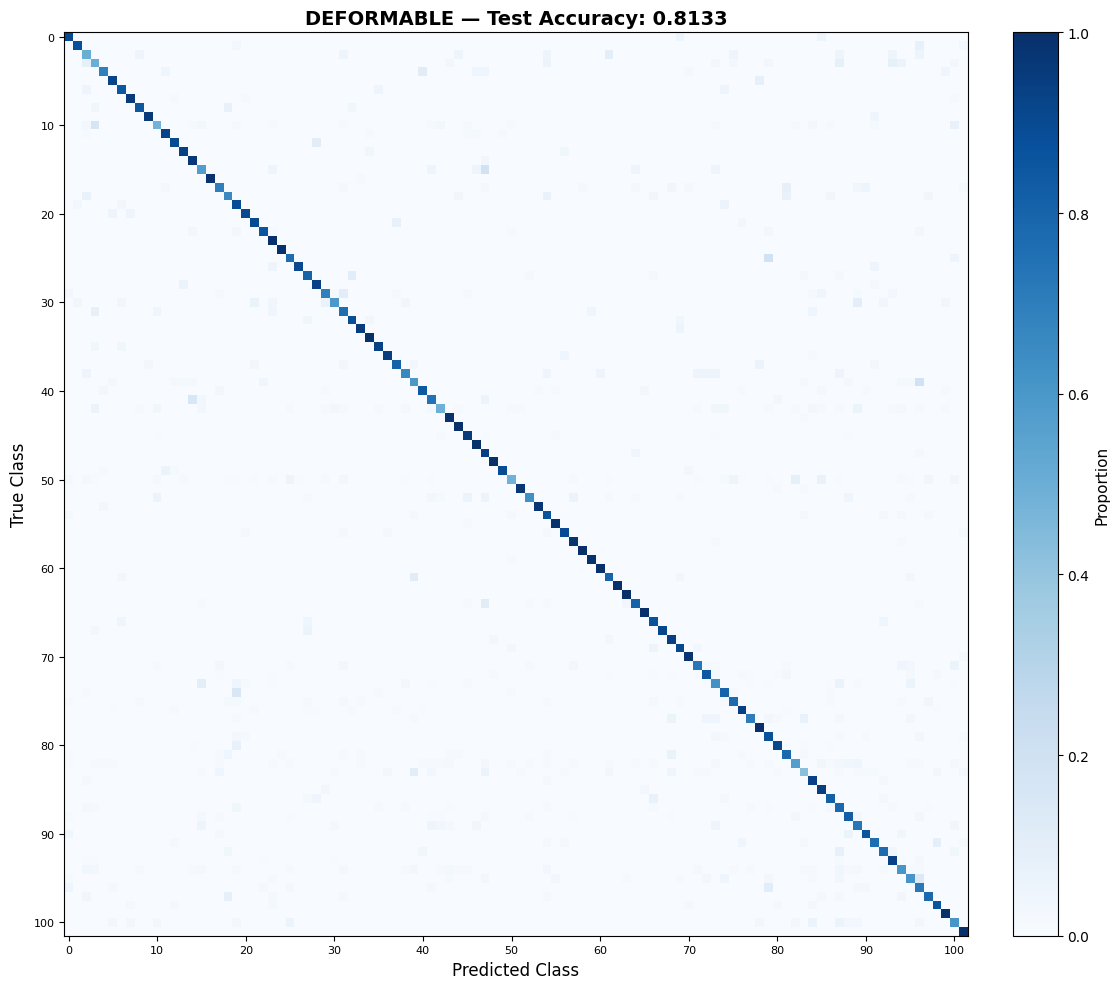

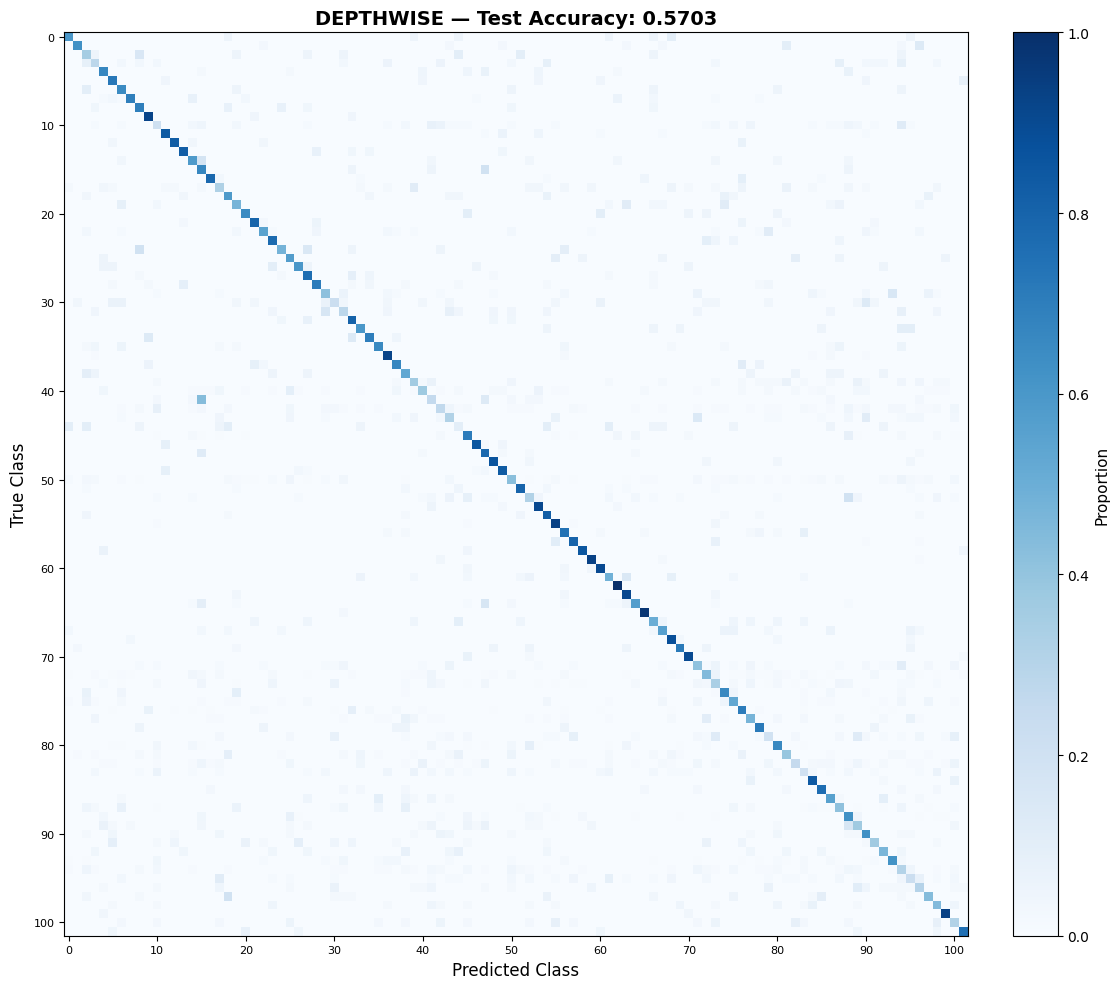

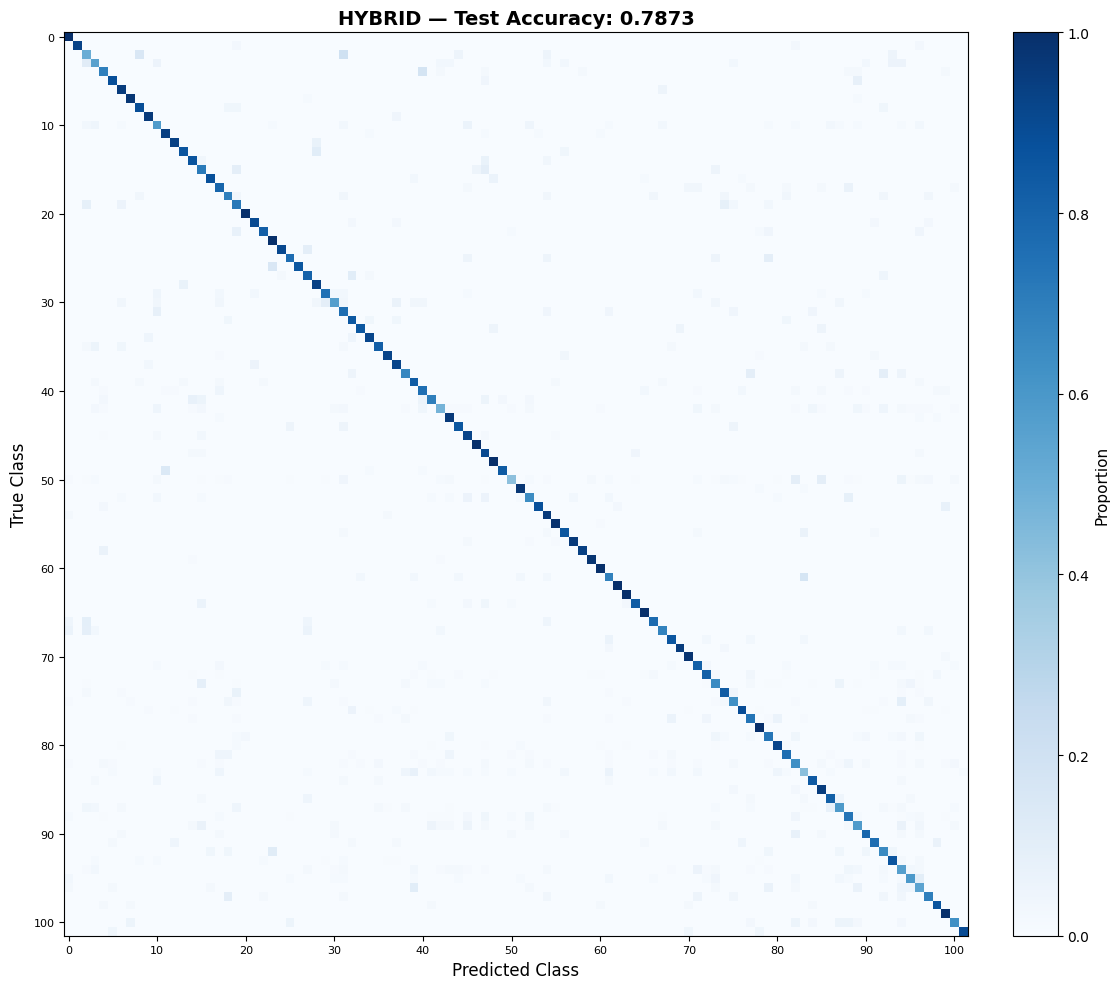

In [6]:
# Plot individual confusion matrices - normalized, with colorbar
if results:
    for name, res in results.items():
        cm = confusion_matrix(res['labels'], res['preds'], normalize='true')
        
        fig, ax = plt.subplots(figsize=(12, 10))
        im = ax.imshow(cm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
        ax.set_title(f"{name.upper()} — Test Accuracy: {res['acc']:.4f}", fontsize=14, fontweight='bold')
        ax.set_xlabel('Predicted Class', fontsize=12)
        ax.set_ylabel('True Class', fontsize=12)
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Proportion', fontsize=11)
        
        # Tick marks every 10 classes
        ticks = list(range(0, 102, 10))
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.tick_params(labelsize=8)
        
        plt.tight_layout()
        plt.savefig(f'../results/logs/{name}_confusion_matrix.png', dpi=150, bbox_inches='tight')
        plt.show()
        print()

BASELINE: Top 10 Best Classes
  Class 101: 1.0000 (28/28 correct)
  Class  99: 1.0000 (29/29 correct)
  Class  65: 1.0000 (41/41 correct)
  Class  78: 1.0000 (21/21 correct)
  Class  70: 1.0000 (58/58 correct)
  Class  63: 1.0000 (32/32 correct)
  Class  46: 1.0000 (47/47 correct)
  Class  44: 1.0000 (20/20 correct)
  Class  24: 1.0000 (21/21 correct)
  Class  14: 1.0000 (29/29 correct)

BASELINE: Top 10 Worst Classes
  Class  50: 0.5000 (119/238 correct)
  Class  83: 0.5303 (35/66 correct)
  Class   3: 0.5556 (20/36 correct)
  Class  30: 0.5938 (19/32 correct)
  Class  82: 0.5946 (66/111 correct)
  Class  10: 0.5970 (40/67 correct)
  Class  42: 0.6000 (66/110 correct)
  Class  96: 0.6087 (28/46 correct)
  Class   2: 0.6500 (13/20 correct)
  Class  52: 0.6575 (48/73 correct)


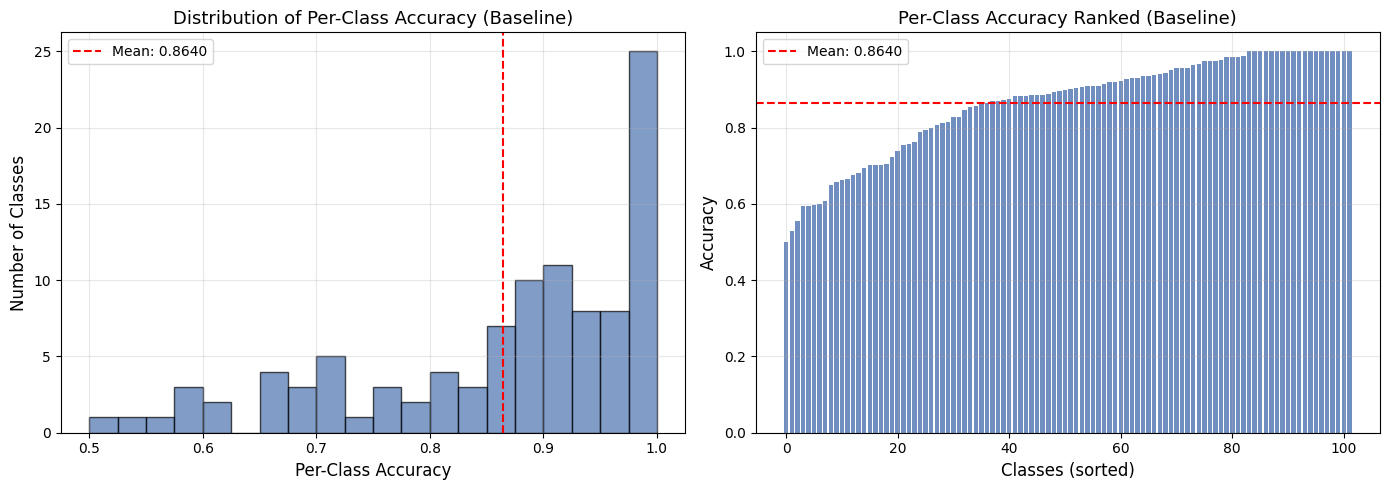

In [7]:
# Analyze per-class accuracy for the baseline model
if 'baseline' in results:
    res = results['baseline']
    cm = confusion_matrix(res['labels'], res['preds'])
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    
    # Sort by per-class accuracy
    sorted_idx = np.argsort(per_class_acc)
    
    n_show = 10
    print(f"{'='*50}")
    print(f"BASELINE: Top {n_show} Best Classes")
    print(f"{'='*50}")
    for i in sorted_idx[-n_show:][::-1]:
        count = cm.sum(axis=1)[i]
        print(f"  Class {i:>3d}: {per_class_acc[i]:.4f} ({int(cm.diagonal()[i])}/{int(count)} correct)")
    
    print(f"\n{'='*50}")
    print(f"BASELINE: Top {n_show} Worst Classes")
    print(f"{'='*50}")
    for i in sorted_idx[:n_show]:
        count = cm.sum(axis=1)[i]
        print(f"  Class {i:>3d}: {per_class_acc[i]:.4f} ({int(cm.diagonal()[i])}/{int(count)} correct)")
    
    # Plot per-class accuracy distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram of per-class accuracies
    axes[0].hist(per_class_acc, bins=20, edgecolor='black', alpha=0.7, color='#4C72B0')
    axes[0].axvline(per_class_acc.mean(), color='red', linestyle='--', label=f'Mean: {per_class_acc.mean():.4f}')
    axes[0].set_xlabel('Per-Class Accuracy', fontsize=12)
    axes[0].set_ylabel('Number of Classes', fontsize=12)
    axes[0].set_title('Distribution of Per-Class Accuracy (Baseline)', fontsize=13)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Sorted per-class accuracy bar plot
    axes[1].bar(range(102), per_class_acc[sorted_idx], color='#4C72B0', alpha=0.8)
    axes[1].axhline(per_class_acc.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {per_class_acc.mean():.4f}')
    axes[1].set_xlabel('Classes (sorted)', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Per-Class Accuracy Ranked (Baseline)', fontsize=13)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/logs/per_class_accuracy_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

## Best & Worst Performing Classes

## Per-Class Classification Reports

In [8]:
# Print classification reports
for name, res in results.items():
    print(f"\n{'='*60}")
    print(f"Classification Report: {name}")
    print(f"{'='*60}")
    report = classification_report(res['labels'], res['preds'])
    print(report)
    
    # Save to file
    with open(f'../results/logs/{name}_classification_report.txt', 'w') as f:
        f.write(f"Model: {name}\nTest Accuracy: {res['acc']:.4f}\n\n{report}")


Classification Report: baseline
              precision    recall  f1-score   support

           0       0.56      0.90      0.69        20
           1       1.00      0.97      0.99        40
           2       0.33      0.65      0.43        20
           3       0.47      0.56      0.51        36
           4       0.92      0.80      0.86        45
           5       0.82      0.92      0.87        25
           6       0.80      1.00      0.89        20
           7       0.91      0.98      0.95        65
           8       0.53      0.92      0.68        26
           9       1.00      1.00      1.00        25
          10       0.77      0.60      0.67        67
          11       0.86      0.96      0.91        67
          12       0.82      0.97      0.89        29
          13       0.81      0.93      0.87        28
          14       0.91      1.00      0.95        29
          15       0.25      0.86      0.39        21
          16       1.00      0.89      0.94     

## Accuracy Comparison Bar Chart

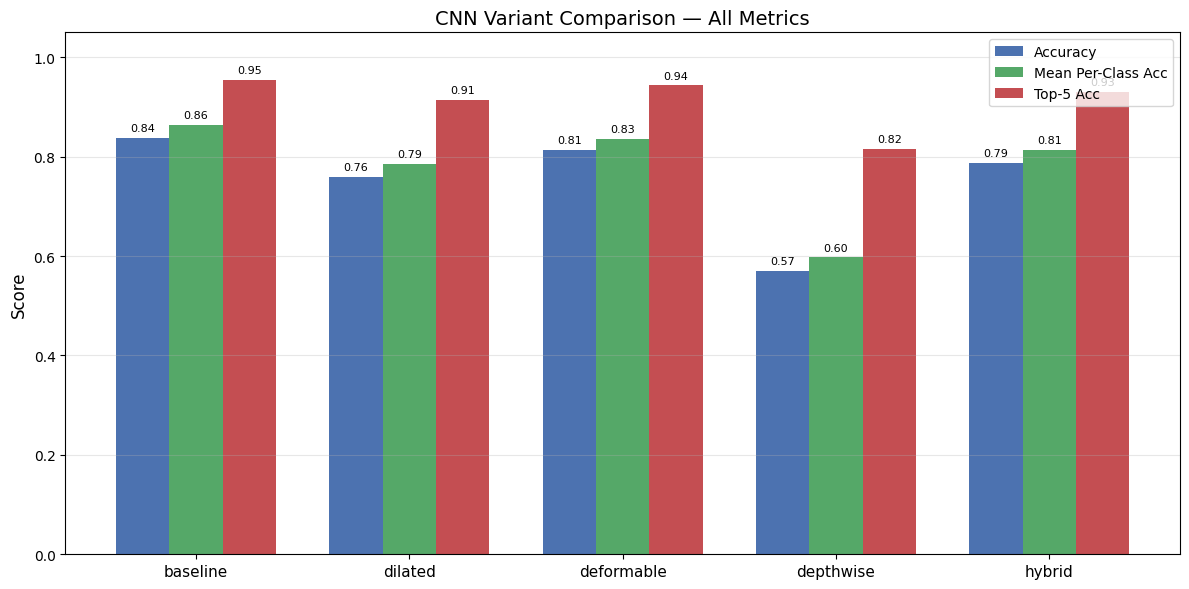

In [9]:
if results:
    names = list(results.keys())
    accs = [results[n]['acc'] for n in names]
    mpc_accs = [results[n]['mean_per_class_acc'] for n in names]
    top5_accs = [results[n]['top5_acc'] for n in names]
    
    x = np.arange(len(names))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - width, accs, width, label='Accuracy', color='#4C72B0')
    bars2 = ax.bar(x, mpc_accs, width, label='Mean Per-Class Acc', color='#55A868')
    bars3 = ax.bar(x + width, top5_accs, width, label='Top-5 Acc', color='#C44E52')
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('CNN Variant Comparison — All Metrics', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=11)
    ax.legend(fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig('../results/logs/accuracy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## Training Curves Comparison

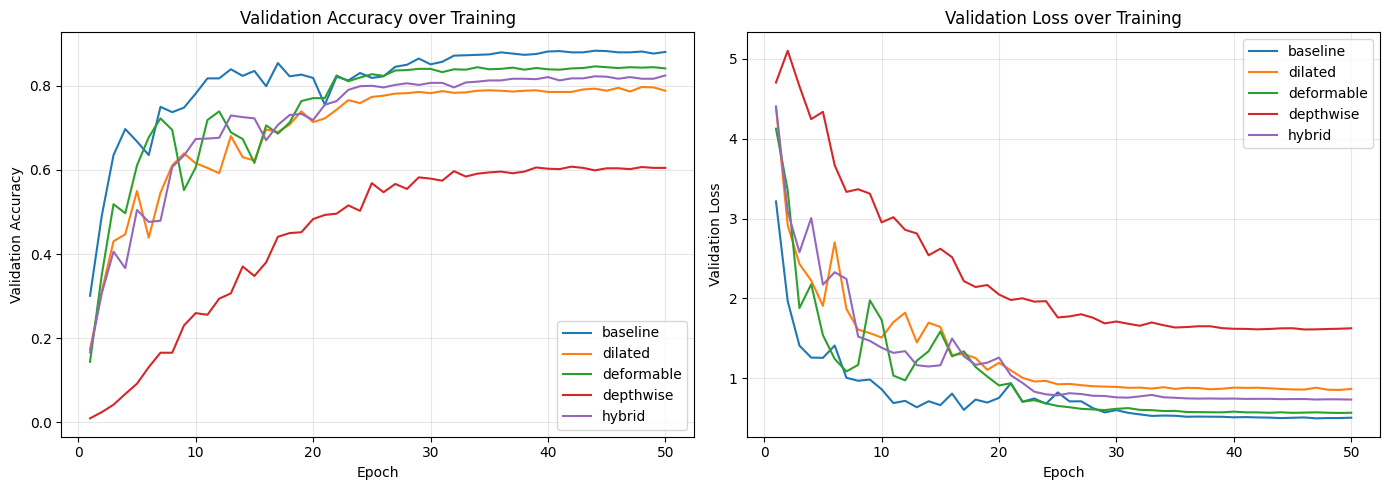

In [10]:
# Load and plot training logs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name in MODEL_REGISTRY.keys():
    log_path = f'../results/logs/{model_name}_training_log.csv'
    if os.path.exists(log_path):
        df = pd.read_csv(log_path)
        axes[0].plot(df['epoch'], df['val_acc'], label=model_name, linewidth=1.5)
        axes[1].plot(df['epoch'], df['val_loss'], label=model_name, linewidth=1.5)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Validation Accuracy over Training')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Validation Loss over Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/logs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()